In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.manifold import TSNE

In [19]:
from google.colab import files
# Load the dataset
uploaded = files.upload()

Saving Molecules_Toxicity_Classification.csv to Molecules_Toxicity_Classification (2).csv


In [20]:
data = pd.read_csv("Molecules_Toxicity_Classification (2).csv")
data.drop("Unnamed: 0", inplace=True, axis=1)
encoder = LabelEncoder()
data["Class"] = encoder.fit_transform(data["Class"])
X = data.drop("Class", axis=1)
y = data["Class"]

In [21]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Apply SMOTE and RandomOverSampler to the FULL scaled data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)


# PCA Alone (2D Visualization)

We apply PCA to reduce the dimensionality of the training data to 2 components for visualization.
This is done for the original dataset, and after applying SMOTE and Random Oversampling.

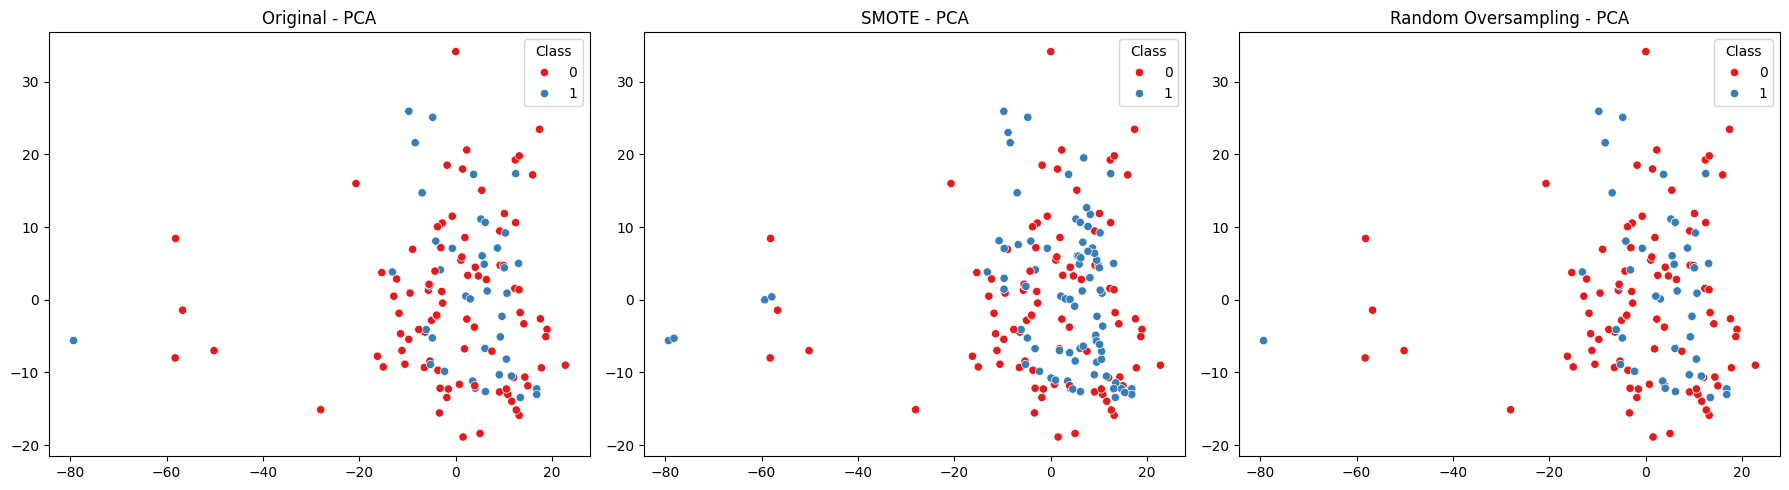

In [24]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_smote_pca = pca.transform(X_train_smote)
X_ros_pca = pca.transform(X_train_ros)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1')
plt.title("Original - PCA")

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_smote_pca[:, 0], y=X_smote_pca[:, 1], hue=y_train_smote, palette='Set1')
plt.title("SMOTE - PCA")

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_ros_pca[:, 0], y=X_ros_pca[:, 1], hue=y_train_ros, palette='Set1')
plt.title("Random Oversampling - PCA")

plt.tight_layout()
plt.show()


# t-SNE Alone (2D Visualization)

Here, we apply t-SNE directly on the high-dimensional scaled data, and visualize the structure of the original, SMOTE, and Random Oversampled datasets.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


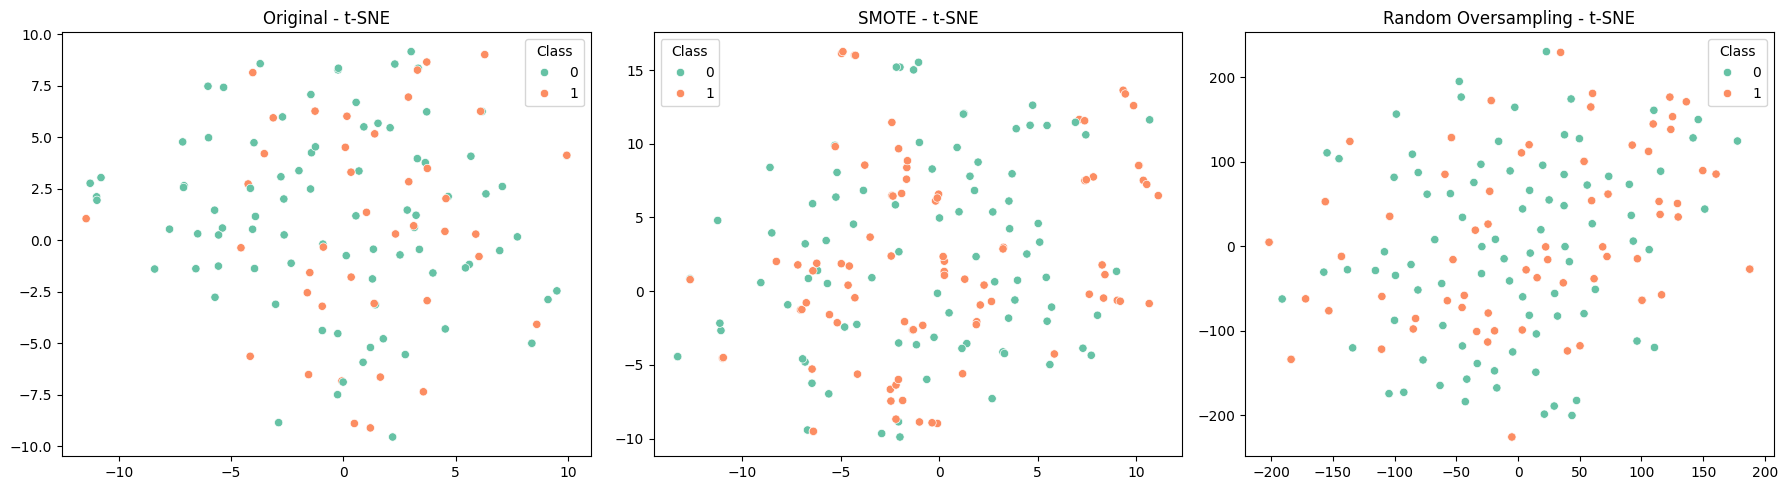

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

X_train_tsne = tsne.fit_transform(X_train_scaled)
X_smote_tsne = tsne.fit_transform(X_train_smote)
X_ros_tsne = tsne.fit_transform(X_train_ros)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], hue=y_train, palette='Set2')
plt.title("Original - t-SNE")

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_smote_tsne[:, 0], y=X_smote_tsne[:, 1], hue=y_train_smote, palette='Set2')
plt.title("SMOTE - t-SNE")

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_ros_tsne[:, 0], y=X_ros_tsne[:, 1], hue=y_train_ros, palette='Set2')
plt.title("Random Oversampling - t-SNE")

plt.tight_layout()
plt.show()


# PCA + t-SNE Combined (Per Dataset)

We apply PCA followed by t-SNE **independently for each dataset** (original, SMOTE, and Random Oversampling).
This allows PCA to capture meaningful directions after oversampling, rather than forcing the oversampled
data to follow the PCA of the original distribution. PCA reduces to 50D, then t-SNE to 2D. This approach
helps t-SNE perform better by eliminating noise and reducing dimensionality before applying the
computationally expensive t-SNE.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
<ipython-input-27-a53686d6a698>:20: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(x=X_tsne_original[:, 0], y=X_tsne_original[:, 1], hue=y_original, palette=sns.color_palette("tab10"))
<ipython-input-27-a53686d6a698>:24: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(x=X_tsne_smote[:, 0], y=X_tsne_smote[:, 1], hue=y_s

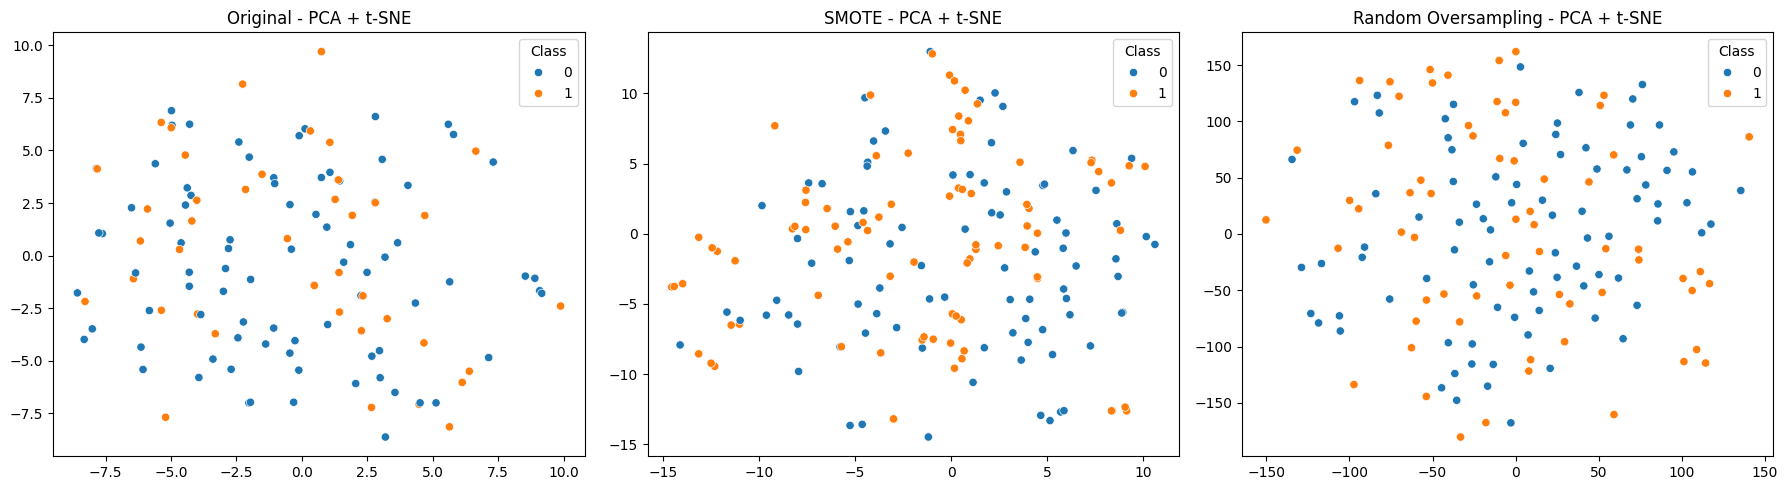

In [27]:
# Function to apply PCA then t-SNE
def pca_tsne_pipeline(X_scaled, y, label):
    pca_50 = PCA(n_components=50, random_state=42)
    X_pca50 = pca_50.fit_transform(X_scaled)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_pca50)

    return X_tsne, y

# Apply independently for each dataset
X_tsne_original, y_original = pca_tsne_pipeline(X_train_scaled, y_train, "Original")
X_tsne_smote, y_smote = pca_tsne_pipeline(X_train_smote, y_train_smote, "SMOTE")
X_tsne_ros, y_ros = pca_tsne_pipeline(X_train_ros, y_train_ros, "Random Oversampling")

# Plot
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=X_tsne_original[:, 0], y=X_tsne_original[:, 1], hue=y_original, palette=sns.color_palette("tab10"))
plt.title("Original - PCA + t-SNE")

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_tsne_smote[:, 0], y=X_tsne_smote[:, 1], hue=y_smote, palette=sns.color_palette("tab10"))
plt.title("SMOTE - PCA + t-SNE")

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_tsne_ros[:, 0], y=X_tsne_ros[:, 1], hue=y_ros, palette=sns.color_palette("tab10"))
plt.title("Random Oversampling - PCA + t-SNE")

plt.tight_layout()
plt.show()
